# 09. 生成モデル — GAN と拡散モデル

## この章で分かること

- **生成モデル**: データの分布そのものを学び、新しいサンプルを作る
- **GAN**: 生成器と識別器の **敵対的** な競争で本物そっくりを作る
- **モード崩壊**: GAN が一部のモードしか作らなくなる問題
- **拡散モデル**: ノイズを少しずつ加える/取り除く過程として生成を捉える

08 章の VAE も生成モデルでした。本章は別系統の 2 つ、GAN と拡散を扱います。
重い学習は避け、2 次元データと小さなデモで **仕組みの直感** を掴むことに集中します。

```{admonition} 核心 — ひとことで
:class: tip
**生成モデルは「データの分布そのもの」を学んで新しいサンプルを作る。GAN は競争、拡散はノイズ付加と除去。**
GAN は生成器（贋作師）と識別器（鑑定士）の敵対で本物そっくりを作る（損失は振動＝均衡探し）。
拡散はデータにノイズを足す閉形式の前向き過程と、加わったノイズを予測して取り除く学習済み逆過程の反復。
```

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
import torch
import torch.nn as nn

from nn_textbook import datasets, plotting
from nn_textbook.training import get_device, set_seed

set_seed(0)
# Committed outputs use the CPU; set NN_TEXTBOOK_GPU=1 to run on the GPU.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
pio.renderers.default = "plotly_mimetype+notebook_connected"
np.set_printoptions(precision=3, suppress=True)
print("device:", device)

device: cpu


## 1. Intuition — 贋作師と鑑定士

GAN は 2 つのネットの競争です。

- **生成器 (Generator)**: ノイズ $z$ から偽サンプルを作る「贋作師」
- **識別器 (Discriminator)**: 本物か偽物かを見分ける「鑑定士」

両者を交互に鍛えます。鑑定士は見破ろうとし、贋作師は騙そうとする。
均衡では、贋作師の作るものが本物の分布と区別できなくなります。

$$
\min_G \max_D \; \mathbb{E}_{x \sim \text{data}}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))]
$$

2 次元の混合ガウス(リング状)を本物データに使い、学習過程を可視化します。

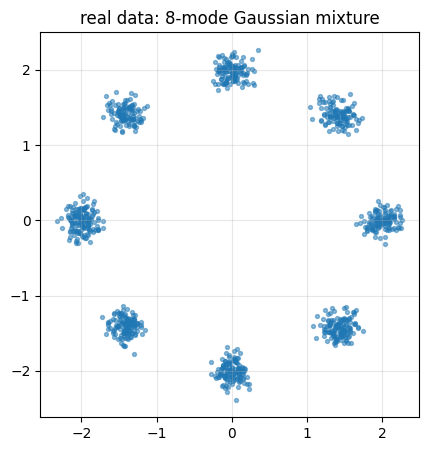

In [2]:
# Real data: a ring of Gaussian blobs (8 modes). Easy to see what the GAN covers.
X_real, _ = datasets.make_gaussian_mixture_dataset(n=1000, n_components=8, radius=2.0, std=0.12, seed=0)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_real[:, 0], X_real[:, 1], s=8, alpha=0.5)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_title("real data: 8-mode Gaussian mixture")
plt.show()

## 2. Computation — 2D GAN を学習する

`nn_textbook.models.make_gan_2d` は小さな生成器・識別器を返します。
学習中、生成サンプルがどう本物分布に近づくかをスナップショットで見ます。

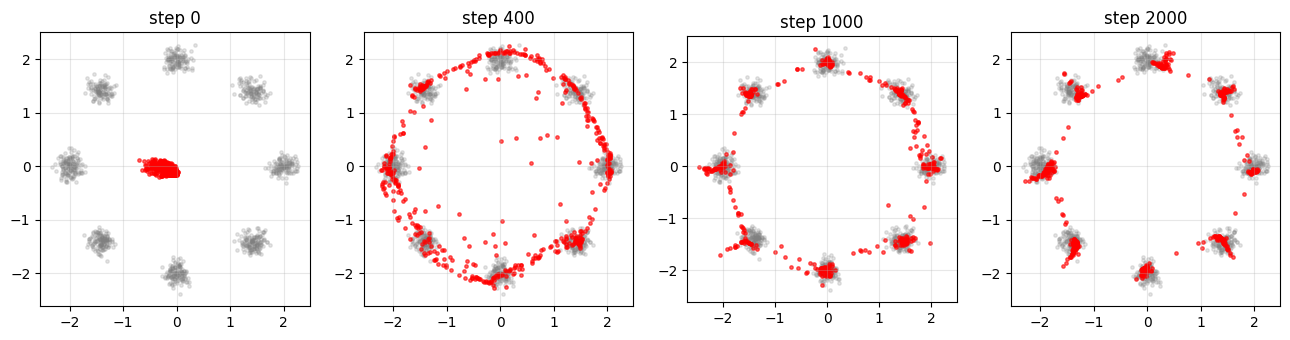

In [3]:
# Train a small 2-D GAN and snapshot generated samples over training.
from nn_textbook.models import make_gan_2d

set_seed(0)
G, D = make_gan_2d(latent_dim=2, hidden=64)
G, D = G.to(device), D.to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.9))
bce = nn.BCEWithLogitsLoss()
real = torch.tensor(X_real).to(device)
batch = 256
ones = torch.ones(batch, 1, device=device)
zeros = torch.zeros(batch, 1, device=device)

snapshots = {}
for step in range(2001):
    # --- train discriminator ---
    idx = torch.randint(0, len(real), (batch,))
    x_real = real[idx]
    z = torch.randn(batch, 2, device=device)
    x_fake = G(z).detach()
    opt_D.zero_grad()
    loss_D = bce(D(x_real), ones) + bce(D(x_fake), zeros)
    loss_D.backward(); opt_D.step()
    # --- train generator (wants D to call fakes real) ---
    z = torch.randn(batch, 2, device=device)
    opt_G.zero_grad()
    loss_G = bce(D(G(z)), ones)
    loss_G.backward(); opt_G.step()
    if step in (0, 400, 1000, 2000):
        with torch.no_grad():
            snapshots[step] = G(torch.randn(500, 2, device=device)).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (step, fake) in zip(axes, snapshots.items(), strict=True):
    ax.scatter(X_real[:, 0], X_real[:, 1], s=6, alpha=0.2, color="gray")
    ax.scatter(fake[:, 0], fake[:, 1], s=6, alpha=0.6, color="red")
    ax.set_aspect("equal"); ax.set_title(f"step {step}"); ax.grid(alpha=0.3)
plt.show()

赤(生成)が灰色(本物)のリングに近づいていきます。

## 3. 生成器 vs 識別器のダイナミクス

GAN 学習は協調ではなく **競争** なので、損失は単調に下がりません。
両者の損失が拮抗しながら推移するのが健全な学習です。

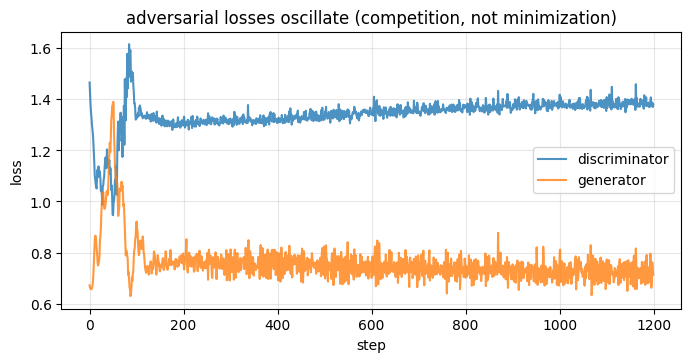

In [4]:
# Track G and D losses: in a healthy GAN they oscillate around an equilibrium.
set_seed(1)
G, D = make_gan_2d(latent_dim=2, hidden=64)
G, D = G.to(device), D.to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.9))
hist_G, hist_D = [], []
for step in range(1200):
    idx = torch.randint(0, len(real), (batch,))
    z = torch.randn(batch, 2, device=device)
    opt_D.zero_grad()
    lD = bce(D(real[idx]), ones) + bce(D(G(z).detach()), zeros)
    lD.backward(); opt_D.step()
    z = torch.randn(batch, 2, device=device)
    opt_G.zero_grad()
    lG = bce(D(G(z)), ones)
    lG.backward(); opt_G.step()
    hist_G.append(lG.item()); hist_D.append(lD.item())

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(hist_D, label="discriminator", alpha=0.8)
ax.plot(hist_G, label="generator", alpha=0.8)
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("adversarial losses oscillate (competition, not minimization)")
plt.show()

## 4. Failure Mode — モード崩壊

GAN の代表的な失敗が **モード崩壊**: 生成器が本物の一部のモードだけを作り、
多様性を失う現象です。識別器を騙すには「確実に本物らしい 1 種類」を作れば十分、
という近視眼的な解に陥るためです。わざと不安定な設定で再現します。

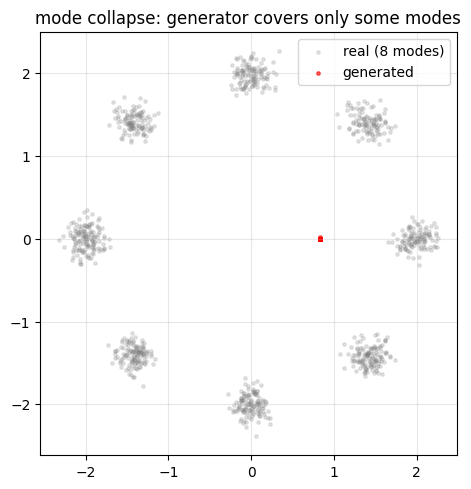

In [5]:
# Mode collapse: an unbalanced setup makes G cover only a few of the 8 modes.
set_seed(3)
G, D = make_gan_2d(latent_dim=2, hidden=32)
G, D = G.to(device), D.to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=5e-3)          # G too fast, no momentum tricks
opt_D = torch.optim.Adam(D.parameters(), lr=5e-4)
for step in range(1800):
    idx = torch.randint(0, len(real), (batch,))
    z = torch.randn(batch, 2, device=device)
    opt_D.zero_grad()
    lD = bce(D(real[idx]), ones) + bce(D(G(z).detach()), zeros)
    lD.backward(); opt_D.step()
    z = torch.randn(batch, 2, device=device)
    opt_G.zero_grad()
    bce(D(G(z)), ones).backward(); opt_G.step()

with torch.no_grad():
    fake = G(torch.randn(800, 2, device=device)).cpu().numpy()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X_real[:, 0], X_real[:, 1], s=6, alpha=0.2, color="gray", label="real (8 modes)")
ax.scatter(fake[:, 0], fake[:, 1], s=6, alpha=0.6, color="red", label="generated")
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("mode collapse: generator covers only some modes")
plt.show()

生成サンプルがリングの一部のかたまりに集中し、全モードを覆えていません。
対策(特徴マッチング・minibatch discrimination・WGAN・spectral norm など)は活発な研究領域です。

## 5. 拡散モデル — ノイズを足して、取り除く

**拡散モデル** は生成を 2 つの過程で考えます。

- **前向き過程 (forward)**: データに少しずつガウスノイズを足し、最終的に純粋なノイズにする(学習不要)
- **逆過程 (reverse)**: ノイズから少しずつノイズを除去してデータを復元する(ここを学習する)

前向き過程は閉じた式で書けます($\bar{\alpha}_t$ は残る信号の割合):

$$
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

まず前向き過程(ノイズを足す)を画像で見ます。

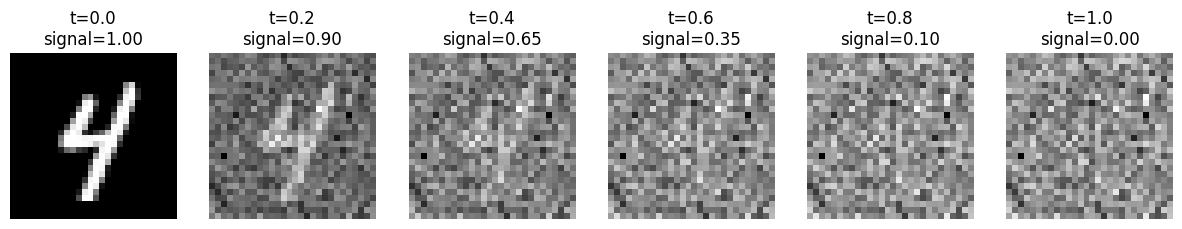

In [6]:
# Forward diffusion: progressively add noise until the image is pure noise.
img = np.asarray(datasets.load_mnist(train=True, n=1, seed=5)[0][0]).squeeze()


def alpha_bar(t):
    # Cosine schedule: signal fraction goes smoothly 1 -> 0 as t: 0 -> 1.
    return np.cos(t * np.pi / 2) ** 2


rng = np.random.default_rng(0)
noise = rng.standard_normal(img.shape)
ts = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 3))
for ax, t in zip(axes, ts, strict=True):
    a = alpha_bar(t)
    xt = np.sqrt(a) * img + np.sqrt(1 - a) * noise
    ax.imshow(xt, cmap="gray"); ax.axis("off")
    ax.set_title(f"t={t:.1f}\nsignal={a:.2f}")
plt.show()

### インタラクティブ: 前向き拡散(JupyterLab のみ)

タイムステップ $t$ をスライダーで動かしてノイズ付加を見るデモです。静的 HTML では上の図を参照。

In [7]:
# Interactive (JupyterLab only): slide t to add noise step by step.
from nn_textbook.widgets import diffusion_noising_explorer

diffusion_noising_explorer(img)

interactive(children=(FloatSlider(value=0.3, description='t', max=1.0, step=0.05), Output()), _dom_classes=('w…

<function nn_textbook.widgets.diffusion_noising_explorer.<locals>.draw(t)>

こちらは **静的 HTML でも動く** Plotly 版です(各 $t$ のノイズ画像を事前計算してフレーム化)。

In [8]:
# Plotly version of the forward-noising slider: works in the exported HTML.
t_grid = np.linspace(0, 1, 21)
frames = [np.sqrt(alpha_bar(t)) * img + np.sqrt(1 - alpha_bar(t)) * noise for t in t_grid]
fig = plotting.plotly_image_slider(frames, labels=[f"{t:.2f}" for t in t_grid],
                                   slider_name="t", title="forward diffusion")
fig.show()

## 6. 逆過程を学ぶ — 1D デノイジングのおもちゃ

逆過程の本質は「ノイズの乗ったデータを見て、**加わったノイズを予測する**」ことです。
分かりやすさのため、1 次元の混合分布で、各ノイズレベルに対し
「きれいなサンプルを予測する」小さなデノイザを学習します。

In [9]:
# A toy 1-D diffusion: learn to denoise samples back toward a bimodal distribution.
def sample_bimodal(n, seed=0):
    rng = np.random.default_rng(seed)
    comp = rng.integers(0, 2, n)
    return (np.where(comp == 0, -2.0, 2.0) + 0.3 * rng.standard_normal(n)).astype(np.float32)


from nn_textbook.models import make_denoiser

x0 = torch.tensor(sample_bimodal(4000))[:, None].to(device)

# Denoiser: given (noisy x, noise level t) predict the clean x0.
denoiser = make_denoiser(input_dim=1, hidden=64).to(device)
opt = torch.optim.Adam(denoiser.parameters(), lr=1e-3)
for step in range(3000):
    idx = torch.randint(0, len(x0), (256,))
    clean = x0[idx]
    t = torch.rand(256, 1, device=device)
    a = torch.cos(t * np.pi / 2) ** 2
    noisy = torch.sqrt(a) * clean + torch.sqrt(1 - a) * torch.randn_like(clean)
    pred = denoiser(noisy, t)
    loss = ((pred - clean) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print(f"final denoising loss: {loss.item():.4f}")

final denoising loss: 1.1895


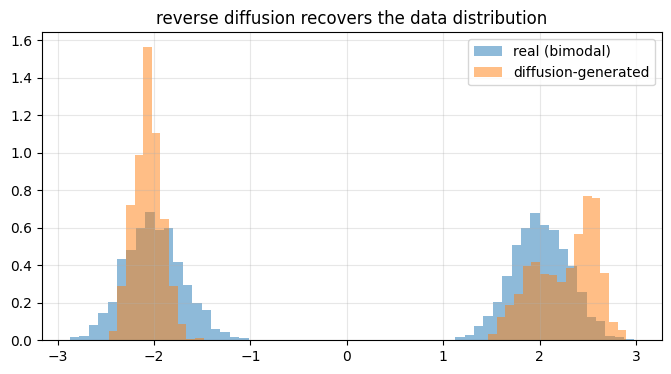

In [10]:
# Reverse process: start from noise, denoise step by step, recover the bimodal shape.
@torch.no_grad()
def sample_reverse(denoiser, n=2000, steps=50):
    x = torch.randn(n, 1, device=device) * 2.0    # start as noise
    for s in reversed(range(1, steps + 1)):
        t = torch.full((n, 1), s / steps, device=device)
        x0_pred = denoiser(x, t)
        a_now = float(np.cos(s / steps * np.pi / 2) ** 2)
        a_next = float(np.cos((s - 1) / steps * np.pi / 2) ** 2)
        # Move a little toward the predicted clean sample (DDIM-style step).
        eps = (x - np.sqrt(a_now) * x0_pred) / np.sqrt(1 - a_now + 1e-6)
        x = np.sqrt(a_next) * x0_pred + np.sqrt(1 - a_next) * eps
    return x.cpu().numpy().ravel()


generated = sample_reverse(denoiser)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(x0.cpu().numpy().ravel(), bins=60, density=True, alpha=0.5, label="real (bimodal)")
ax.hist(generated, bins=60, density=True, alpha=0.5, label="diffusion-generated")
ax.legend(); ax.grid(alpha=0.3); ax.set_title("reverse diffusion recovers the data distribution")
plt.show()

ノイズから出発した逆過程が、本物の二峰性分布を再現できています。
これがまさに、画像生成の拡散モデル(DDPM / Stable Diffusion 等)の縮小版です。

## 7. スコアの直感(高レベル)

拡散モデルは、各ノイズレベルでの **スコア** $\nabla_x \log p(x)$
(「データが濃い方向」を指すベクトル場)を学んでいる、とも解釈できます。

- スコアは「もっともらしい方向」への矢印
- 逆過程は、この矢印に沿ってノイズを少しずつデータに引き寄せる

「ノイズ予測」「スコア推定」「デノイジング」は、拡散の枠組みで本質的に同じものです
(詳細は Advanced Notes)。

## 8. Failure Mode — 生成モデルの難しさ

| モデル | 主な難しさ |
|---|---|
| GAN | 学習が不安定・モード崩壊・収束判定が難しい |
| VAE(08章) | 生成がぼやけがち・posterior collapse |
| 拡散 | サンプリングが遅い(多ステップ)・計算が重い |

評価も難しく、「本物らしさ」と「多様性」の両立を測る指標(FID 等)が使われます。

## 9. Application — 生成モデルの現在

- **画像生成**: 拡散モデル(Stable Diffusion・DALL·E)が主流
- **GAN**: 高速生成・超解像・画像編集で今も使われる
- **音声・動画・分子・3D**: 生成モデルの応用は急拡大中
- **言語生成**: 自己回帰 Transformer(07・10 章)が別系統で支配的

「データ分布を学んで新しいものを作る」生成モデルは、AI の最も活発な領域のひとつです。

```{admonition} 実社会では
:class: important
「データ分布を学んで新しいものを作る」生成モデルは、AI で最も活発な領域です。

- 画像：拡散モデル（Stable Diffusion・DALL·E）が主流、GAN は高速生成・超解像・編集で現役。
- 音声・動画・分子・3D へ急拡大、言語は自己回帰 Transformer（10 章）が支配的。
- 実用の選択はトレードオフで決まる：速いが不安定な GAN、遅いが安定な拡散、ぼやけがちな VAE。
```

## 10. まとめ

- 生成モデルは **データ分布そのもの** を学ぶ。VAE(08 章)・GAN・拡散の三系統。
- **GAN** は生成器と識別器の競争。損失が振動するのは正常(最小化ではなく均衡探し)。
- **モード崩壊** = 一部モードへの質量集中(本章ではリングの一部の弧として再現)。
- **拡散** = ノイズ付加(閉形式)+ 学習した逆過程(ノイズ予測 ≒ スコア推定)の反復。
- 速くて不安定な GAN、遅くて安定な拡散 — トレードオフが実用上の選択を決める。

## 11. Exercises

1. 2D GAN のモード数(`n_components`)を 4 / 8 / 16 と変え、学習の難しさを比べよ。
2. 健全な GAN とモード崩壊 GAN の生成分布を、ヒストグラムや 2D 散布で定量的に比較せよ。
3. 拡散のスケジュール(`alpha_bar`)を線形に変え、前向き過程の見た目がどう変わるか観察せよ。
4. 1D 拡散デノイザの逆過程ステップ数を 5 / 20 / 50 と変え、生成分布の質を比べよ。
5. 1D の本物分布を三峰性に変え、デノイザが全モードを復元できるか確認せよ。
6. (発展)2D の混合ガウスに拡散デノイザを適用し、リング分布を生成してみよ。

## 12. Advanced Notes

**GAN の理論的最適解。** 識別器が最適なとき、生成器の目的は本物分布 $p_\text{data}$ と
生成分布 $p_g$ の Jensen-Shannon ダイバージェンスの最小化に等しくなります。
実際には最適識別器は得られず、勾配消失やモード崩壊が起きるため、
WGAN(Wasserstein 距離)や勾配ペナルティなど、より安定な定式化が提案されています。

**拡散と denoising score matching。** ノイズレベル $t$ で加えたノイズ $\epsilon$ を予測することは、
スコア $\nabla_x \log p_t(x)$ を推定することと等価(Tweedie の公式で結ばれる)。
逆過程は確率微分方程式(逆向き SDE)の離散化と見なせ、本章の DDIM 風ステップは
その決定論的版(ODE)に対応します。

**サンプリング高速化。** DDPM は数百〜千ステップ必要でしたが、DDIM・蒸留・consistency models
などで数ステップ生成が可能になっています。本章のおもちゃは 50 ステップの DDIM 風です。

**生成モデルの三系統。** VAE(尤度ベース・潜在変数)、GAN(暗黙的・敵対的)、
拡散(尤度ベース・反復的)。それぞれ尤度・サンプル品質・多様性・学習安定性のトレードオフが異なり、
用途に応じて使い分け・融合されています。